In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [3]:
df = pd.read_csv('house_price_linear_regression.csv')

In [4]:
df.head(10)

,Area_sqft,Bedrooms,Age_years,Distance_city_km,Price_lakhs
0,1360,2,8,7,45.34
1,1794,1,27,3,62.80
2,1630,5,26,17,96.51
3,1595,3,5,1,92.12
4,2138,4,15,16,106.69
5,2669,3,28,12,86.23
6,966,3,2,19,86.68
7,1738,1,19,22,87.17
8,830,3,27,23,34.57
9,1982,5,26,22,93.48


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Area_sqft         100 non-null    int64  
 1   Bedrooms          100 non-null    int64  
 2   Age_years         100 non-null    int64  
 3   Distance_city_km  100 non-null    int64  
 4   Price_lakhs       100 non-null    float64
dtypes: float64(1), int64(4)
memory usage: 4.0 KB


In [6]:
df['Price_lakhs'] = df['Price_lakhs'].abs()

In [7]:
df.columns

Index(['Area_sqft', 'Bedrooms', 'Age_years', 'Distance_city_km',
       'Price_lakhs'],
      dtype='object')

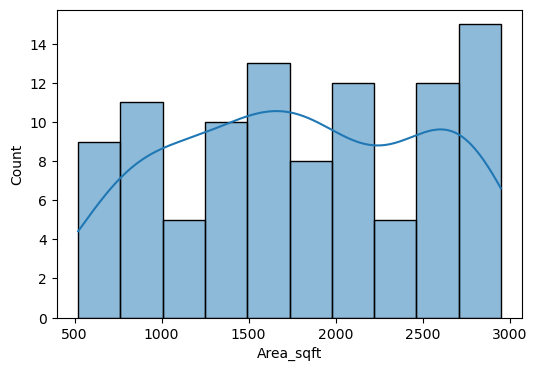

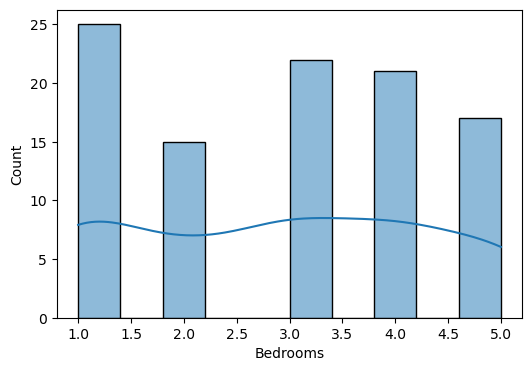

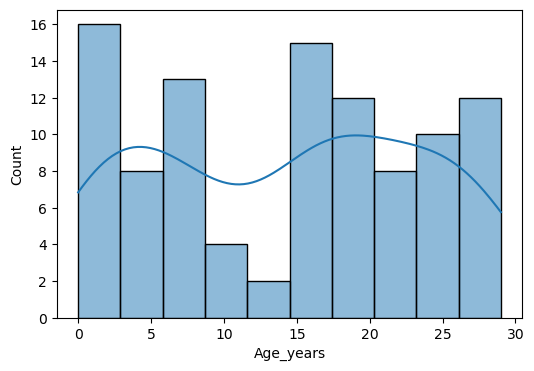

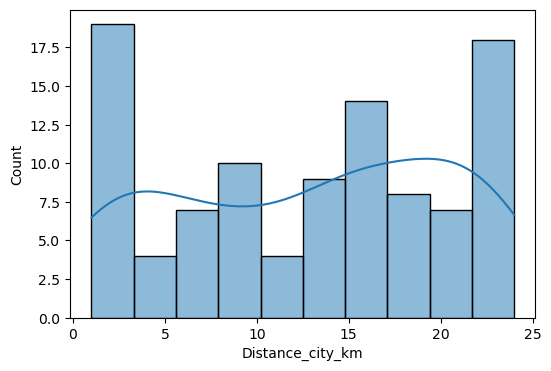

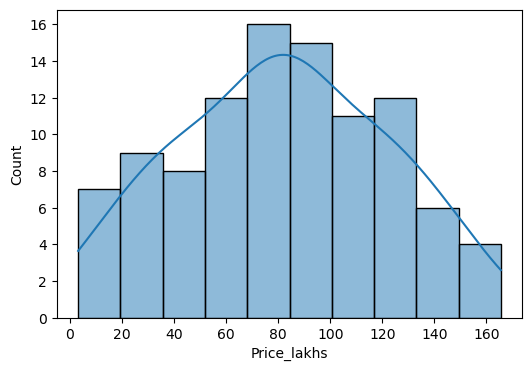

In [8]:
numeric_columns = ['Area_sqft', 'Bedrooms', 'Age_years', 'Distance_city_km', 'Price_lakhs']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=10) # creating histogram to check distribution

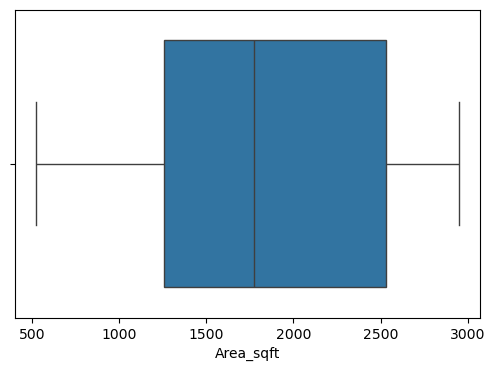

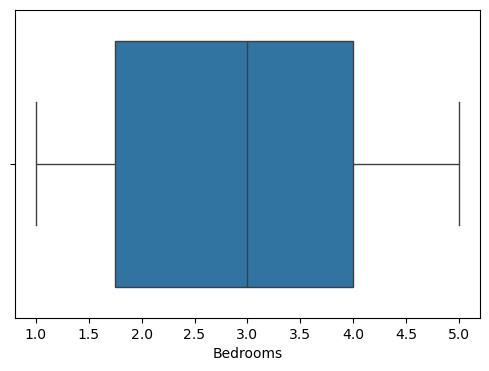

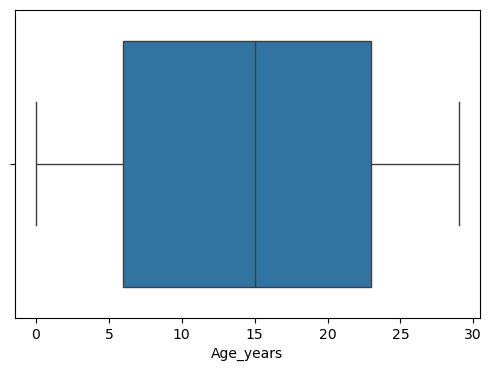

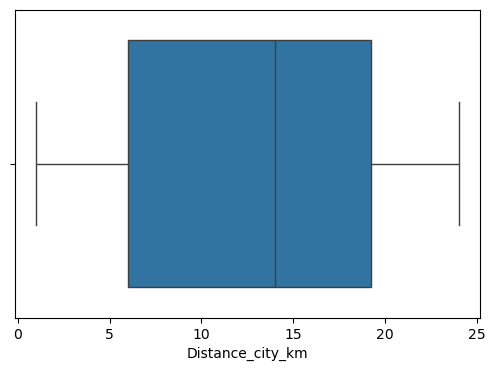

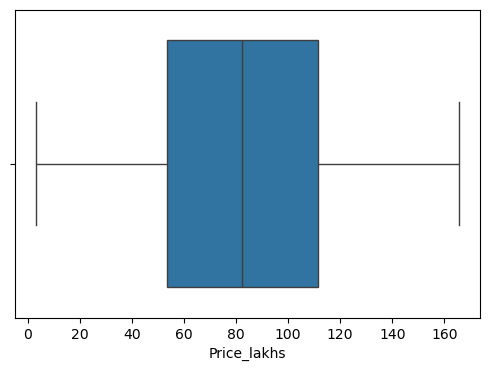

In [9]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x = df[col]) #for check outliers

In [10]:
#we don't have any outliers

<Axes: >

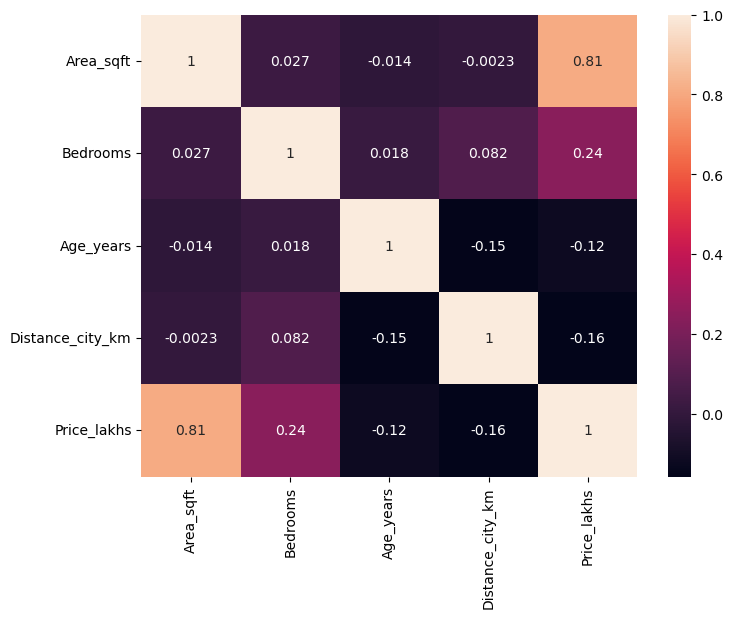

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True) # check co-relation between columns

In [12]:
df[['Area_sqft', 'Bedrooms', 'Age_years', 'Distance_city_km', 'Price_lakhs']].corr() #Feature Analysis

,Area_sqft,Bedrooms,Age_years,Distance_city_km,Price_lakhs
Area_sqft,1.000000,0.026691,-0.014087,-0.002283,0.806672
Bedrooms,0.026691,1.000000,0.018107,0.082462,0.241696
Age_years,-0.014087,0.018107,1.000000,-0.152318,-0.119735
Distance_city_km,-0.002283,0.082462,-0.152318,1.000000,-0.158063
Price_lakhs,0.806672,0.241696,-0.119735,-0.158063,1.000000


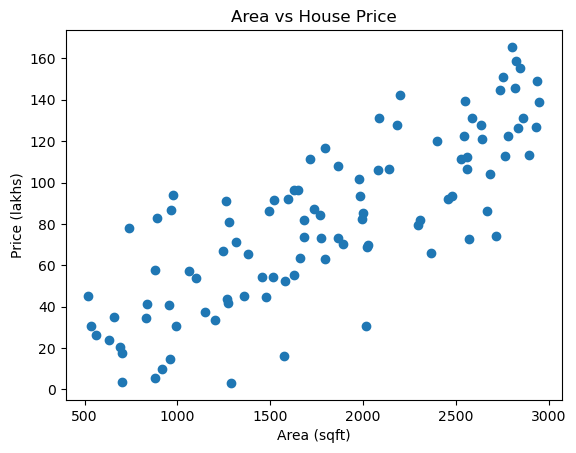

In [13]:
plt.figure()
plt.scatter(df['Area_sqft'], df['Price_lakhs'])
plt.xlabel('Area (sqft)')
plt.ylabel('Price (lakhs)')
plt.title('Area vs House Price')
plt.show()

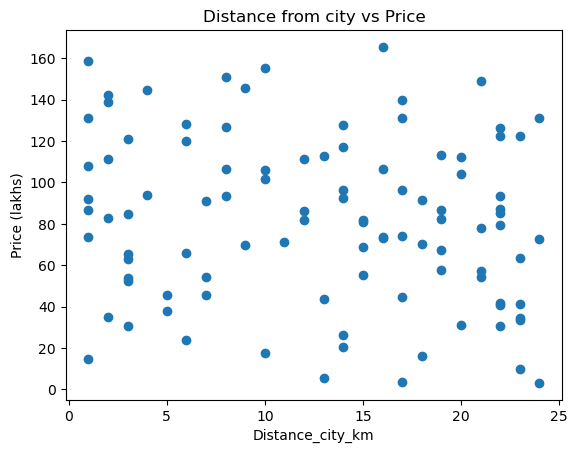

In [14]:
plt.figure()
plt.scatter(df['Distance_city_km'], df['Price_lakhs'])
plt.xlabel('Distance_city_km')
plt.ylabel('Price (lakhs)')
plt.title('Distance from city vs Price')
plt.show()

# Split features & target

In [15]:
X = df[['Area_sqft', 'Bedrooms', 'Age_years', 'Distance_city_km']]
y = df['Price_lakhs']

# Model Building

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [18]:
# model.intercept_
model.coef_

array([ 0.04065187,  6.56911427, -0.74746204, -1.03492778])

In [19]:
pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

,Feature,Coefficient
0,Area_sqft,0.040652
1,Bedrooms,6.569114
2,Age_years,-0.747462
3,Distance_city_km,-1.034928


In [20]:
# If the house area increases by 100 sqft, how much does the price increase
# Price increases 0.040652 lakhs per 1 sqft
# means 100 * 0.040 =~ 4 Lakh
# Is this model suitable for production? Why or why not?
# --> No,May be limited feature
# Add more meaningful features 

In [21]:
# Make prediction

In [22]:
X_test

,Area_sqft,Bedrooms,Age_years,Distance_city_km
83,1652,5,17,14
53,2085,4,8,24
70,837,4,5,23
45,1863,2,15,1
44,2541,3,0,23
39,2935,4,24,21
22,521,4,17,5
80,2562,2,28,8
10,2635,3,3,14
0,1360,2,8,7


In [23]:
y_test

83     96.18
53    131.28
70     41.28
45    108.14
44    122.55
39    148.82
22     45.36
80    106.34
10    127.85
0      45.34
18     54.47
30     20.30
73      3.14
33     84.50
90      9.94
4     106.69
76    144.81
77      5.36
12    128.01
31     57.14
Name: Price_lakhs, dtype: float64

In [24]:
model.predict([[1652 , 5 ,17 ,14]])

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([85.46951544])

In [25]:
y_pred = model.predict(X_test)

"""
MAE tells the average prediction error in real units, MSE penalizes large errors, 
and R² shows how much variance in the target variable is explained by the model.
An R² of 0.8 means the model explains 80% of price variation.
"""
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAR", mean_absolute_error(y_test, y_pred))

R2 Score: 0.7855238855927833
MSE: 487.60522736986997
MAR 19.108592817006876


In [26]:
# using standard Scalar
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Fit on training data
scaler.fit(X_train)
# Transform
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print("Predictions:", y_pred)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

Predictions: [ 85.46951544  92.880542    45.4243206   89.28870265 111.86330512
 118.58002323  42.23748481 100.74285967 122.75654489  67.86347904
  70.37464646  42.58445324  38.33713912 106.17150253  37.07381771
  98.08227911 104.59876819  23.57185539 109.4366887   32.13264394]
MAE: 19.108592817007008
R2 Score: 0.7855238855927806
